# Data Story

The analysis of the Titanic dataset reveals several interesting patterns. Most passengers did not survive the disaster. Women had a significantly higher survival rate than men, suggesting that rescue efforts prioritized women and children. The majority of passengers were young adults between 20 and 40 years old. Passengers travelling in first class generally paid higher fares and also had better chances of survival. The correlation analysis shows that fare and passenger class are related, while age and fare have a weak relationship.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [4]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [14]:
df['Age'].fillna(df['Age'].median(),inplace=True)

C:\Users\Khushi Agarwal\AppData\Local\Temp\ipykernel_18924\1527141296.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(),inplace=True)


In [15]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [18]:
df.drop('Cabin',axis=1,inplace=True)

KeyError: "['Cabin'] not found in axis"

In [19]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [21]:
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)

In [22]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [23]:
##EDA

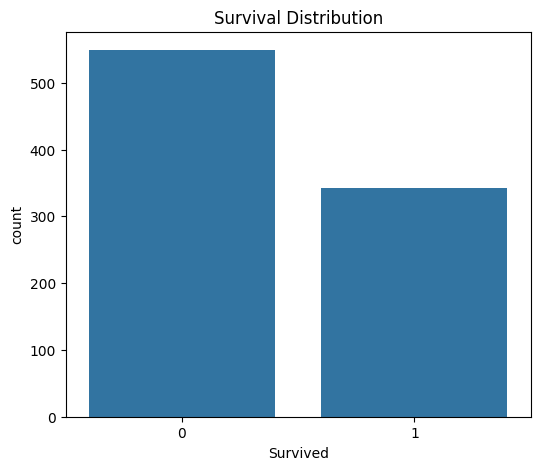

In [25]:
plt.figure(figsize=(6,5))
sns.countplot(x='Survived' ,data=df)
plt.title('Survival Distribution')
plt.savefig('chart1_survival_distribution.png')
plt.show()

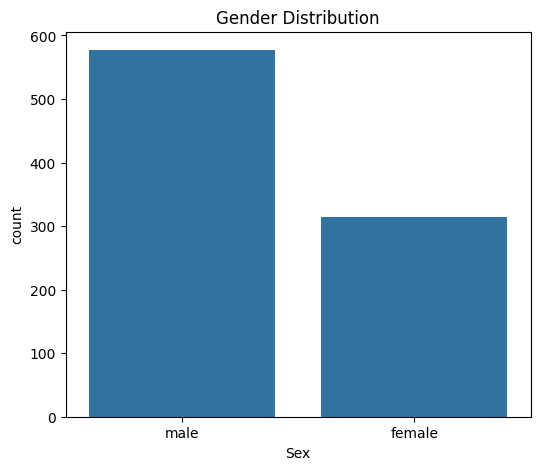

In [39]:
plt.figure(figsize=(6,5))
sns.countplot(x='Sex' ,data=df)
plt.title('Gender Distribution')
plt.savefig('chart2_survival_distribution.png')
plt.show()

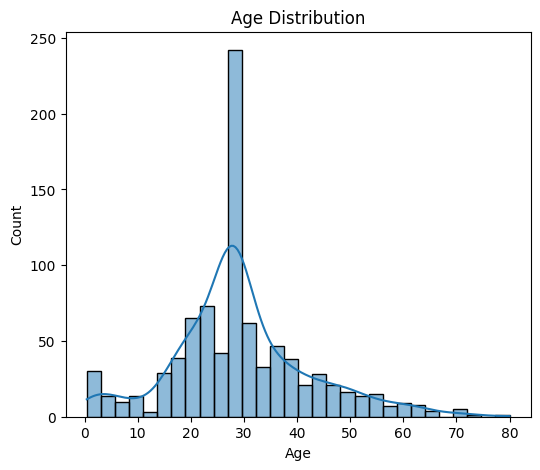

In [38]:
plt.figure(figsize=(6,5))
sns.histplot(df["Age"],bins=30,kde=True)
plt.title('Age Distribution')
plt.savefig('chart3_survival_distribution.png')
plt.show()

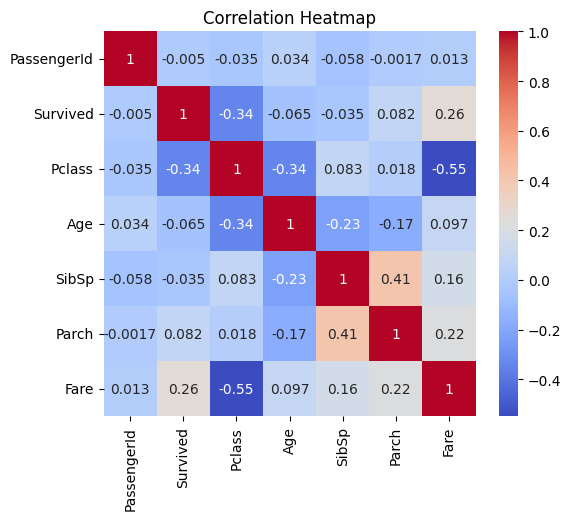

In [30]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(6,5))
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('chart4_correlation_heatmap.png')
plt.show()

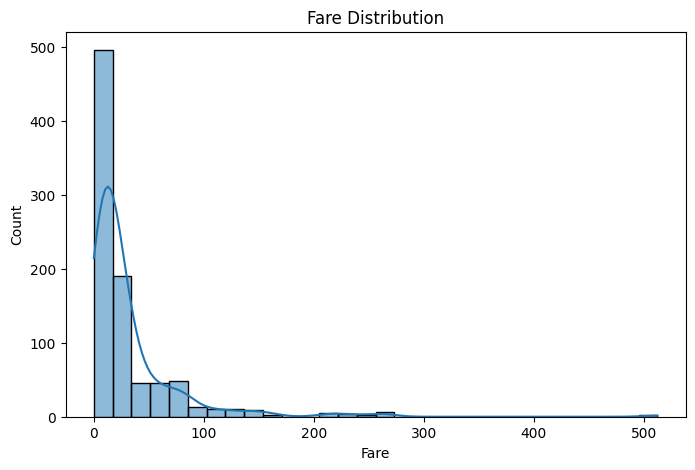

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df['Fare'], bins=30, kde=True)
plt.title('Fare Distribution')
plt.savefig('chart5_fare_distribution.png')
plt.show()

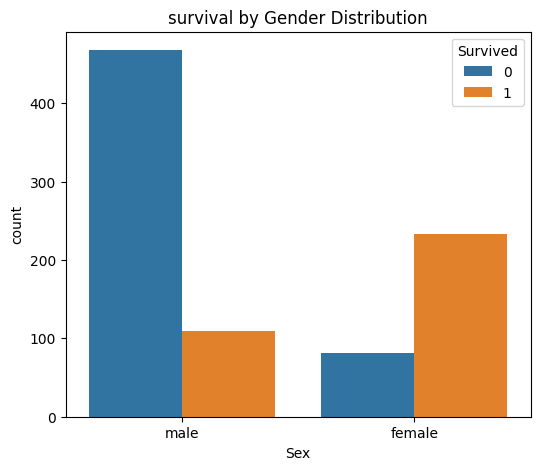

In [37]:
plt.figure(figsize=(6,5))
sns.countplot(x='Sex', hue='Survived',data=df)
plt.title('survival by Gender Distribution')
plt.savefig('chart6_survival_distribution.png')
plt.show()

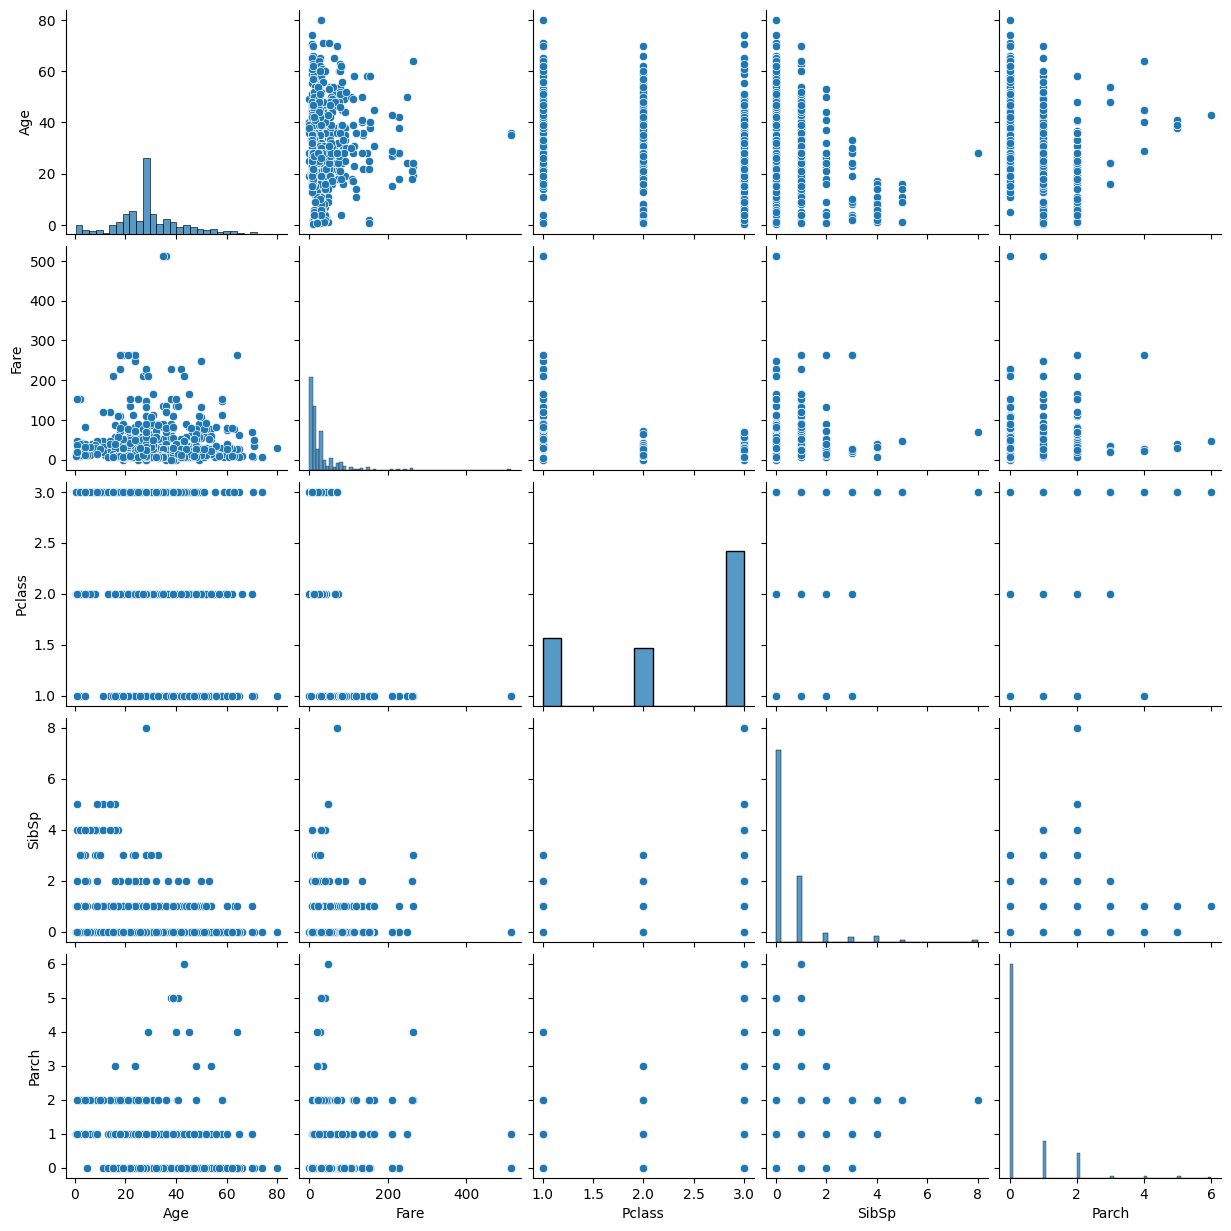

In [36]:
pair_df = df[['Age','Fare','Pclass','SibSp','Parch']]

sns.pairplot(pair_df)
plt.savefig('chart7_pairplot.png')
plt.show()